# **LangChain Neo4j**

## 학습 목표
- Neo4j와 LangChain 통합 방법 이해
- Neo4jGraph를 활용한 Cypher 쿼리 실행
- Neo4jChatMessageHistory로 대화 이력을 그래프로 관리
- Neo4jVector를 이용한 벡터 검색 및 하이브리드 검색 구현
- GraphCypherQAChain으로 자연어 기반 그래프 QA 시스템 구축

## 사전 준비
- Neo4j 데이터베이스 (AuraDB 또는 로컬 설치)
- 환경 변수 설정 (.env 파일): NEO4J_URI, NEO4J_USERNAME, NEO4J_PASSWORD, OPENAI_API_KEY
- 필수 패키지: langchain-neo4j, langchain-openai, python-dotenv

---

## **기본 개요**

- **LangChain과 Neo4j 그래프 데이터베이스의 통합** 기능 제공
- Neo4j 데이터베이스와 LangChain을 함께 사용하여 **AI 기반 지식 그래프 애플리케이션** 구축
- **설치**: `pip install -U langchain-neo4j`
- **공식 문서**: [LangChain Neo4j Integration](https://python.langchain.com/docs/integrations/graphs/neo4j_cypher/)

- **주요 활용 사례**
    - **지식 그래프 기반 RAG**: 복잡한 관계 정보를 활용한 검색 증강 생성
    - **대화형 AI 시스템**: 문맥을 유지하는 챗봇 및 가상 어시스턴트
    - **의미론적 검색**: 벡터 임베딩과 그래프 구조를 결합한 하이브리드 검색
    - **추천 시스템**: 관계 기반 개인화 추천 엔진

- **핵심 컴포넌트 소개**
    1. **Neo4jGraph**: 그래프 데이터베이스 연결 및 Cypher 쿼리 실행
    2. **Neo4jChatMessageHistory**: 대화 이력 그래프 저장
    3. **Neo4jVector**: 벡터 기반 의미론적 검색
    4. **GraphCypherQAChain**: 자연어-Cypher 변환 및 QA

## **1. Neo4jGraph**

- **Neo4jGraph** 클래스는 Neo4j Python 드라이버를 래핑하여 **간단한 인터페이스** 제공
- Neo4j 데이터베이스와의 상호 작용 및 기본적인 **Cypher 쿼리** 실행이 가능

> 💡 **LangChain ⇄ Neo4j 통합 전체 지도** — 이 노트북에서 배울 4가지 컴포넌트
>
```mermaid
graph TB
    U([사용자 요청]) --> APP[LangChain 앱]
    APP --> A[Neo4jGraph<br/>직접 Cypher 실행]
    APP --> B[Neo4jChatMessageHistory<br/>대화 이력 저장]
    APP --> C[Neo4jVector<br/>의미 기반 검색]
    APP --> D[GraphCypherQAChain<br/>자연어 → Cypher 자동변환]
    A --> DB[(Neo4j DB)]
    B --> DB
    C --> DB
    D --> DB
    style A fill:#e1f5ff
    style B fill:#fff4e1
    style C fill:#e8f5e9
    style D fill:#fce4ec
```

> 🔑 **역할 한 줄 요약**
> - **Neo4jGraph**: 직접 Cypher 쿼리 실행용 (초저수준).
> - **ChatMessageHistory**: 사용자/AI 메시지를 그래프에 누적 저장 — **세션 ID** 로 구분.
> - **Neo4jVector**: 문서 임베딩 + 벡터 유사도 검색 (노드 속성에 벡터 저장).
> - **GraphCypherQAChain**: "자연어 질문 → LLM → Cypher → 실행 → 답변" 를 체인 한 방으로.


### **1.1 기본 연결 설정**

In [1]:
import os
from dotenv import load_dotenv
from langchain_neo4j import Neo4jGraph

# 환경 변수 로드
load_dotenv()

# 최신 Neo4jGraph 연결 
graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"), 
    username=os.getenv("NEO4J_USERNAME"), 
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE"),  # 명시적 데이터베이스 지정
    refresh_schema=True,  # 스키마 자동 갱신
    enhanced_schema=True  # 향상된 스키마 정보 제공
)

# 연결 상태 확인
try:
    print(f"database: {os.getenv('NEO4J_DATABASE')}")
    result = graph.query("RETURN 'Neo4j 연결 성공!' as message")
    print(f"연결 결과: {result[0]}")
except Exception as e:
    print(f"연결 실패: {e}")

/Users/seungiljang/workspace/004_prj/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


database: 0f869be1
연결 결과: {'message': 'Neo4j 연결 성공!'}


### **1.2 쿼리 실행**

In [48]:
# 성능 모니터링과 함께 쿼리 실행
def execute_with_monitoring(graph, query, parameters=None):
    """모니터링 기능이 포함된 쿼리 실행"""
    import time
    
    start_time = time.time()
    try:
        result = graph.query(query, parameters or {})
        execution_time = time.time() - start_time
        
        return {
            "success": True,
            "data": result,
            "execution_time": execution_time,
            "query": query
        }
    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "execution_time": time.time() - start_time,
            "query": query
        }

# 사용 예제
result = execute_with_monitoring(graph, "MATCH (n) RETURN count(n) as node_count")
if result["success"]:
    print(f"노드 개수: {result['data'][0]['node_count']}")
    print(f"실행 시간: {result['execution_time']:.3f}초")
else:
    print(f"오류: {result['error']}")

노드 개수: 28
실행 시간: 0.040초


### **[실습 1]** 

- Neo4j 데이터베이스에 연결하고, 간단한 Cypher 쿼리를 실행하여 전체 노드 개수를 반환하는 코드를 작성하세요.

In [ ]:
# 여기에 코드를 작성하세요. 

from langchain_neo4j import Neo4jGraph

NEO4J_URI = None
NEO4J_USERNAME = None
NEO4J_PASSWORD = None
NEO4J_DATABASE = None

graph = None

query = None
results = None
print(f"노드 개수: {results[0]['count(n)']}")


<details close>
<summary>💡 정답 확인</summary>

```python
from langchain_neo4j import Neo4jGraph
import os

NEO4J_URI = os.getenv("NEO4J_URI")
NEO4J_USERNAME = os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

graph = Neo4jGraph(
    url=NEO4J_URI,
    username=NEO4J_USERNAME,
    password=NEO4J_PASSWORD,
    database=NEO4J_DATABASE
)

query = "MATCH (n) RETURN count(n)"
results = graph.query(query)
print(f"노드 개수: {results[0]['count(n)']}")
```

</details>

## **2. Neo4jChatMessageHistory - 대화 이력 관리**

- **Neo4jChatMessageHistory**는 채팅 메시지를 **구조화된 그래프**로 저장
- **대화 패턴 분석**과 **컨텍스트 추적**이 가능


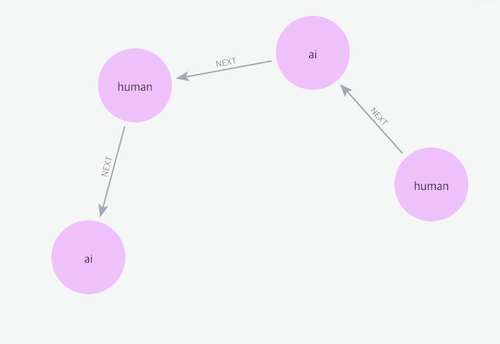

> 💡 **"세션 ID" 가 핵심입니다**
>
> `Neo4jChatMessageHistory` 는 **session_id** 를 키로 삼아 대화를 그래프에 누적합니다. 같은 `session_id` 로 초기화하면 이전 대화가 이어지고, 다른 `session_id` 면 새 대화가 시작됩니다.
>
> 👉 **챗봇 서비스** 라면 → 사용자 ID 또는 세션 쿠키를 그대로 `session_id` 로 사용하세요. LLM 컨텍스트 관리, 대화 분석, 사용자별 이력 복원까지 한 번에 해결됩니다.


### **2.1 대화 이력 관리**

In [13]:
from langchain_neo4j import Neo4jChatMessageHistory
from datetime import datetime

# 고급 설정으로 대화 이력 관리자 초기화
history = Neo4jChatMessageHistory( 
    session_id="session_001",
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database="neo4j",                    # 기본값: "neo4j"
    node_label="Session",                # 기본값: "Session" 
    window=3                             # 조회할 메시지 개수 (최근 3개 메시지만 반환)
                                         # window=3이면 마지막 메시지부터 최대 3개의 메시지 조회
)


# 대화 이력 출력
history.messages

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [14]:
from langchain_core.messages import HumanMessage, AIMessage

# 대화 이력 추가
history.add_user_message(
    HumanMessage(
        content="hi",
        additional_kwargs={"language": "en"}
    )
)
history.add_ai_message(
    AIMessage(
        content="whats up?",
        additional_kwargs={"language": "en"}
    )
)

# 대화 이력 출력
history.messages

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

In [15]:
# 대화 이력 추가 
history.add_user_message("Please tell me about yourself.")
history.add_ai_message("I am an AI assistant.")

# 대화 이력 출력
history.messages

[AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='hi', additional_kwargs={}, response_metadata={}),
 AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

### **[실습 2]** 

- 다음 대화 이력을 기존의 Neo4j 데이터베이스에 추가하세요.

- 대화 이력:
    ```
    User: "안녕하세요, 오늘 날씨가 어떤가요?"
    AI: "안녕하세요! 오늘은 맑고 화창한 날씨가 예상됩니다."
    User: "그럼 산책하기 좋겠네요. 근처 공원을 추천해 줄 수 있나요?"
    AI: "네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다."
    ```

In [16]:
# 여기에 코드를 작성하세요
history.add_user_message("안녕하세요, 오늘 날씨가 어떤가요?")
history.add_ai_message("안녕하세요! 오늘은 맑고 화창한 날씨가 예상됩니다.")
history.add_user_message("그럼 산책하기 좋겠네요. 근처 공원을 추천해 줄 수 있나요?")
history.add_ai_message("네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다.")

# 대화 이력 출력
history.messages


[AIMessage(content='whats up?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='Please tell me about yourself.', additional_kwargs={}, response_metadata={}),
 AIMessage(content='I am an AI assistant.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='안녕하세요, 오늘 날씨가 어떤가요?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='안녕하세요! 오늘은 맑고 화창한 날씨가 예상됩니다.', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='그럼 산책하기 좋겠네요. 근처 공원을 추천해 줄 수 있나요?', additional_kwargs={}, response_metadata={}),
 AIMessage(content="네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다.", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

<details close>
<summary>💡 정답 확인</summary>

```python
history.add_user_message("안녕하세요, 오늘 날씨가 어떤가요?")
history.add_ai_message("안녕하세요! 오늘은 맑고 화창한 날씨가 예상됩니다.")
history.add_user_message("그럼 산책하기 좋겠네요. 근처 공원을 추천해 줄 수 있나요?")
history.add_ai_message("네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다.")

# 대화 이력 출력
history.messages
```

</details>

### **2.2 대화 패턴 분석**

In [41]:
# 그래프 스키마 갱신
graph.refresh_schema()

In [42]:
# 세션 ID 확인
history._session_id

'tech_support'

In [19]:
# 세션 기반 분석 (마지막 메시지 추적)
session_analysis_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾는 쿼리
MATCH (s:Session {id: $session_id})
MATCH (s)-[:LAST_MESSAGE]->(last:Message)  // 세션 노드와 마지막 메시지 노드를 연결하는 관계를 찾음
RETURN 
    s.id as session_id,
    last as last_message
"""

result = graph.query(
    query=session_analysis_query, 
    params={"session_id": history._session_id}
    )
    
result

[{'session_id': 'session_001',
  'last_message': {'createdAt': neo4j.time.DateTime(2026, 4, 29, 11, 47, 19, 828000000, tzinfo=<UTC>),
   'role': 'ai',
   'content': "네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다."}}]

In [20]:
# 세션의 모든 메시지 가져오기 (연결된 체인 따라가기)
conversation_analysis_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾고, 
MATCH (s:Session {id: $session_id})-[:LAST_MESSAGE]->(last:Message)

// 마지막 메시지에서 시작하여 연결된 모든 메시지를 가져오는 쿼리
MATCH path = (first:Message)-[:NEXT*0..]->(last)    // *0..은 0개 이상의 관계를 의미
WHERE NOT EXISTS(()-[:NEXT]->(first))    // 이때 first는 이전 메시지가 없는 첫번째 메시지

// 메시지 노드의 속성을 가져오는 쿼리
WITH nodes(path) as messages  // path를 nodes로 변환 (WITH 구문: 쿼리 결과를 다음 쿼리로 전달)

// 메시지 노드를 UNWIND하여 각 메시지의 속성을 반환 (UNWIND 구문: 리스트를 개별 요소로 분리)
UNWIND messages as msg

// 반환할 메시지의 속성
RETURN 
    msg.content as content,
    msg.role as role,
    msg.createdAt as created_at
ORDER BY msg.createdAt ASC
"""

result = graph.query(
    query=conversation_analysis_query,
    params={"session_id": history._session_id}
)

result

[{'content': 'hi',
  'role': 'human',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 29, 9, 613000000, tzinfo=<UTC>)},
 {'content': 'whats up?',
  'role': 'ai',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 29, 10, 202000000, tzinfo=<UTC>)},
 {'content': 'Please tell me about yourself.',
  'role': 'human',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 29, 16, 45000000, tzinfo=<UTC>)},
 {'content': 'I am an AI assistant.',
  'role': 'ai',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 29, 16, 217000000, tzinfo=<UTC>)},
 {'content': 'hi',
  'role': 'human',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 31, 57, 175000000, tzinfo=<UTC>)},
 {'content': 'whats up?',
  'role': 'ai',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 31, 57, 214000000, tzinfo=<UTC>)},
 {'content': 'Please tell me about yourself.',
  'role': 'human',
  'created_at': neo4j.time.DateTime(2026, 4, 29, 11, 32, 1, 411000000, tzinfo=<UTC>)},
 {'content': 'I am an AI assistant.',
  '

In [21]:
# 대화 이력 출력
for i, record in enumerate(result, 1):
    print(f"{i}. [{record['role'].upper()}] {record['content']} ({record['created_at']})")

1. [HUMAN] hi (2026-04-29T11:29:09.613000000+00:00)
2. [AI] whats up? (2026-04-29T11:29:10.202000000+00:00)
3. [HUMAN] Please tell me about yourself. (2026-04-29T11:29:16.045000000+00:00)
4. [AI] I am an AI assistant. (2026-04-29T11:29:16.217000000+00:00)
5. [HUMAN] hi (2026-04-29T11:31:57.175000000+00:00)
6. [AI] whats up? (2026-04-29T11:31:57.214000000+00:00)
7. [HUMAN] Please tell me about yourself. (2026-04-29T11:32:01.411000000+00:00)
8. [AI] I am an AI assistant. (2026-04-29T11:32:01.448000000+00:00)
9. [HUMAN] 안녕하세요, 오늘 날씨가 어떤가요? (2026-04-29T11:47:19.715000000+00:00)
10. [AI] 안녕하세요! 오늘은 맑고 화창한 날씨가 예상됩니다. (2026-04-29T11:47:19.768000000+00:00)
11. [HUMAN] 그럼 산책하기 좋겠네요. 근처 공원을 추천해 줄 수 있나요? (2026-04-29T11:47:19.799000000+00:00)
12. [AI] 네, 물론입니다. 근처에 '중앙 공원'이 산책하기 아주 좋습니다. (2026-04-29T11:47:19.828000000+00:00)


In [25]:
# 대화 통계 계산
conversation_stats_query = """
// 세션 ID로 세션 노드와 마지막 메시지 노드를 찾고,
MATCH (s:Session {id: $session_id})-[:LAST_MESSAGE]->(last:Message)

// 마지막 메시지에서 시작하여 연결된 모든 메시지를 가져오는 쿼리
MATCH path = (first:Message)-[:NEXT*0..]->(last)
WHERE NOT EXISTS(()-[:NEXT]->(first))   

// 메시지 노드들을 가져오고,
WITH nodes(path) as messages

// 메시지 노드들을 가져오고,
RETURN 
    size(messages) as total_messages,   // 총 메시지 수
    size([msg IN messages WHERE msg.role = 'human']) as user_messages,   // 사용자 메시지 수
    size([msg IN messages WHERE msg.role = 'ai']) as ai_messages,   // AI 메시지 수
    [msg IN messages | msg.role] as message_sequence,   // 메시지 순서
    min([msg IN messages | msg.createdAt]) as conversation_start,   // 대화 시작 시간
    max([msg IN messages | msg.createdAt]) as conversation_end   // 대화 종료 시간
"""

result = graph.query(
    query=conversation_stats_query, 
    params={"session_id": history._session_id}
)

result


[{'total_messages': 12,
  'user_messages': 6,
  'ai_messages': 6,
  'message_sequence': ['human',
   'ai',
   'human',
   'ai',
   'human',
   'ai',
   'human',
   'ai',
   'human',
   'ai',
   'human',
   'ai'],
  'conversation_start': [neo4j.time.DateTime(2026, 4, 29, 11, 29, 9, 613000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 29, 10, 202000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 29, 16, 45000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 29, 16, 217000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 31, 57, 175000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 31, 57, 214000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 32, 1, 411000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 32, 1, 448000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 47, 19, 715000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 4, 29, 11, 47, 19, 768000000, tzinfo=<UTC>),
   neo4j.time.DateTime(2026, 

In [23]:
stats = result[0]
print(f"총 메시지 수: {stats['total_messages']}")
print(f"사용자 메시지: {stats['user_messages']}")
print(f"AI 메시지: {stats['ai_messages']}")
print(f"대화 시작: {stats['conversation_start'][0].to_clock_time()}")
print(f"대화 종료: {stats['conversation_end'][0]}")
print(f"메시지 순서: {' -> '.join(stats['message_sequence'][-10:])}")  # 마지막 10개

총 메시지 수: 12
사용자 메시지: 6
AI 메시지: 6
대화 시작: neo4j.time.ClockTime(seconds=63913058949, nanoseconds=613000000)
대화 종료: 2026-04-29T11:29:09.613000000+00:00
메시지 순서: human -> ai -> human -> ai -> human -> ai -> human -> ai -> human -> ai


/var/folders/6w/3_xp09fd0vq5dsn9k49fxjcr0000gn/T/ipykernel_61334/1968080137.py:5: DeprecationWarning: ClockTime is an implementation detail. It and its related methods will be removed in a future version.
  print(f"대화 시작: {stats['conversation_start'][0].to_clock_time()}")


### **[실습 3]** 

- `Neo4jChatMessageHistory`를 사용하여 간단한 챗봇의 대화 기록을 저장하고 불러오는 코드를 작성하세요. 

In [ ]:
# 여기에 코드를 작성하세요.

from langchain_neo4j import Neo4jChatMessageHistory
import os

# 대화 이력 관리자 초기화
history = Neo4jChatMessageHistory(
    None,
)

# 대화 이력 초기화 (실습을 위해 기존 이력 삭제)
history.clear()

# 메시지 추가
history.add_user_message("안녕하세요!")
history.add_ai_message("안녕하세요. 무엇을 도와드릴까요?")
history.add_user_message("LangChain Neo4j에 대해 알려주세요.")

# 대화 기록 불러오기 및 출력
messages = history.messages
print("대화 기록:")
for message in messages:
    print(f"{message.type}: {message.content}")


<details close>
<summary>💡 정답 확인</summary>

```python
from langchain_neo4j import Neo4jChatMessageHistory
import os

# 대화 이력 관리자 초기화
history = Neo4jChatMessageHistory(
    session_id="chatbot_session_001",
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database="neo4j"
)

# 대화 이력 초기화 (실습을 위해 기존 이력 삭제)
history.clear()

# 메시지 추가
history.add_user_message("안녕하세요!")
history.add_ai_message("안녕하세요. 무엇을 도와드릴까요?")
history.add_user_message("LangChain Neo4j에 대해 알려주세요.")

# 대화 기록 불러오기 및 출력
messages = history.messages
print("대화 기록:")
for message in messages:
    print(f"{message.type}: {message.content}")
```

</details>

### **[실습 4]** 

- `Neo4jChatMessageHistory`를 사용하여 다음 기능을 구현해보세요:

In [ ]:
# 1. 여러 세션의 대화 이력 생성

sessions = ["tech_support", "product_inquiry", "general_chat"]

conversation_data = {
    "tech_support": [
        ("user", "시스템에 오류가 발생했습니다."),
        ("ai", "어떤 종류의 오류인지 더 자세히 설명해주시겠어요?"),
        ("user", "로그인이 안 됩니다."),
        ("ai", "브라우저 캐시를 삭제하고 다시 시도해보세요.")
    ],
    "product_inquiry": [
        ("user", "신제품 출시 일정을 알고 싶습니다."),
        ("ai", "다음 분기에 새로운 제품 라인업이 출시될 예정입니다."),
        ("user", "가격대는 어떻게 되나요?"),
        ("ai", "가격은 기본 모델 기준 $299부터 시작합니다.")
    ],
    "general_chat": [
        ("user", "안녕하세요!"),
        ("ai", "안녕하세요! 무엇을 도와드릴까요?"),
        ("user", "오늘 날씨가 좋네요."),
        ("ai", "네, 정말 좋은 날씨입니다. 다른 도움이 필요하시면 언제든 말씀하세요.")
    ]
}



In [28]:
# 여기에 코드를 작성하세요.
session_histories = {}

for session_id in sessions:
    # 각 세션에 대한 대화 이력 관리자 생성
    history = Neo4jChatMessageHistory(
        session_id=session_id,
        url=os.getenv("NEO4J_URI"),
        username=os.getenv("NEO4J_USERNAME"),
        password=os.getenv("NEO4J_PASSWORD"),
        database="neo4j"
    )
    
    # 기존 이력 삭제
    history.clear()
    
    # 대화 데이터 추가
    for role, content in conversation_data[session_id]:
        if role == "user":
            history.add_user_message(content)
        else:
            history.add_ai_message(content)
    
    session_histories[session_id] = history

print(f"생성된 세션 수: {len(session_histories)}")

생성된 세션 수: 3


<details close>
<summary>💡 정답 확인</summary>

```python
session_histories = {}

for session_id in sessions:
    # 각 세션에 대한 대화 이력 관리자 생성
    history = Neo4jChatMessageHistory(
        session_id=session_id,
        url=os.getenv("NEO4J_URI"),
        username=os.getenv("NEO4J_USERNAME"),
        password=os.getenv("NEO4J_PASSWORD"),
        database="neo4j"
    )
    
    # 기존 이력 삭제
    history.clear()
    
    # 대화 데이터 추가
    for role, content in conversation_data[session_id]:
        if role == "user":
            history.add_user_message(content)
        else:
            history.add_ai_message(content)
    
    session_histories[session_id] = history

print(f"생성된 세션 수: {len(session_histories)}")
```

</details>

In [ ]:
# 2. 세션별 활동 비교
activity_stats = {}

for session_id, history in session_histories.items():
    # TODO: 메시지 개수 계산 
    message_count = None
    
    # TODO: 사용자 메시지 개수 계산
    user_messages = None
    
    # TODO: AI 메시지 개수 계산  
    ai_messages = None
    
    activity_stats[session_id] = {
        'total_messages': message_count,
        'user_messages': user_messages,
        'ai_messages': ai_messages,
        'interaction_ratio': user_messages / message_count if message_count > 0 else 0
    }

# 활동 통계 출력 포맷 개선
for session_id, stats in activity_stats.items():
    print(f"세션 ID: {session_id}")
    print(f"  총 메시지 수: {stats['total_messages']}")
    print(f"  사용자 메시지: {stats['user_messages']}")
    print(f"  AI 메시지: {stats['ai_messages']}")
    print(f"  상호작용 비율: {stats['interaction_ratio']:.2f}\n")


<details close>
<summary>💡 정답 확인</summary>

```python
activity_stats = {}

for session_id, history in session_histories.items():
    # 메시지 개수 계산
    messages = history.messages
    message_count = len(messages)
    
    # 사용자 메시지 개수 계산
    user_messages = len([msg for msg in messages if msg.type == 'human'])
    
    # AI 메시지 개수 계산
    ai_messages = len([msg for msg in messages if msg.type == 'ai'])
    
    activity_stats[session_id] = {
        'total_messages': message_count,
        'user_messages': user_messages,
        'ai_messages': ai_messages,
        'interaction_ratio': user_messages / message_count if message_count > 0 else 0
    }

# 활동 통계 출력
for session_id, stats in activity_stats.items():
    print(f"세션 ID: {session_id}")
    print(f"  총 메시지 수: {stats['total_messages']}")
    print(f"  사용자 메시지: {stats['user_messages']}")
    print(f"  AI 메시지: {stats['ai_messages']}")
    print(f"  상호작용 비율: {stats['interaction_ratio']:.2f}\n")
```

</details>

---

## **3. Neo4jVector - 벡터 검색**

**Neo4jVector**는 **하이브리드 검색**(벡터 + 그래프 관계)을 지원하여 더욱 정확한 의미론적 검색을 제공합니다.


In [2]:
# Article 노드를 조회하는 쿼리
# 주의: 이 셀을 실행하기 전에 Article 노드가 Neo4j에 미리 생성되어 있어야 합니다.
# Article 노드가 없다면 이전 노트북에서 뉴스 기사 데이터를 먼저 로드해주세요.

query = "MATCH (n:Article) RETURN n"

articles = graph.query(query)

print(f"Article 노드 개수: {len(articles)}")

if len(articles) > 0:
    print(articles[0])
else:
    print("Article 노드가 없습니다. 먼저 뉴스 기사 데이터를 로드해주세요.")

Article 노드 개수: 10
{'n': {'wordCount': 245, 'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 15), 'id': 'tech-001', 'source': '테크경제신문', 'title': '엔비디아, AI 반도체 수요 급증으로 실적 고공행진', 'category': 'technology', 'content': '엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특히 데이터센터용 GPU 판매가 크게 증가했으며, 젠슨 황 CEO는 AI 수요가 앞으로도 지속적으로 증가할 것으로 전망했다.'}}


### **3.1 기존 데이터를 활용한 벡터 스토어 구축**

In [3]:
from langchain_core.documents import Document

# 랭체인 문서로 변환 
print(f"Article 노드 개수: {len(articles)}")

docs = [
    Document(
        page_content=f"{article['n'].get('title', '')}\n\n{article['n']['content']}",
        metadata={
            "author": article['n']['author'] or "Unknown",
            "publishDate": article['n']['publishDate'] or "Unknown",
            "source": article['n']['source'] or "Unknown",
        },
    )
    for article in articles
]

print(f"문서 개수: {len(docs)}")
print(docs[0].page_content)
print(docs[0].metadata)

Article 노드 개수: 10
문서 개수: 10
엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특히 데이터센터용 GPU 판매가 크게 증가했으며, 젠슨 황 CEO는 AI 수요가 앞으로도 지속적으로 증가할 것으로 전망했다.
{'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 15), 'source': '테크경제신문'}


In [5]:
from langchain_openai import OpenAIEmbeddings
from langchain_neo4j import Neo4jVector

# 임베딩 모델 초기화
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",  # 최신 모델
    show_progress_bar=True  # 진행률 표시
)

# LangChain 도구 활용 - Neo4j 벡터 스토어 생성
db = Neo4jVector.from_documents(
    docs,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    index_name="article_embeddings",  # 인덱스 이름 명시
    text_node_property="content",  # 텍스트 속성명
    embedding_node_property="embedding",  # 임베딩 속성명
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


### **3.2 다양한 검색 전략**

> 💡 **언제 어떤 검색을 써야 할까?**
>
```mermaid
flowchart LR
    Q([질문]) --> SIM[similarity_search<br/>가장 유사한 top-k]
    Q --> SCORE[similarity_search_with_score<br/>신뢰도 점수 필요할 때]
    Q --> FIL[metadata filter<br/>특정 조건 문서만]
    Q --> MMR[MMR 검색<br/>중복 피하고 다양성 확보]
    SIM --> U1[일반 Q&A]
    SCORE --> U2[임계값 필터링]
    FIL --> U3[카테고리·날짜별]
    MMR --> U4[요약·탐색용]
```

> 🔑 **실전 팁**: 
> - **일반 RAG** → `similarity_search` 로 충분. 
> - **"비슷한 답만 5개" 방지** 하려면 `MMR` (다양성 파라미터 `lambda_mult` 조절). 
> - **점수 < 0.7 은 버리기** 같은 품질 필터가 필요하면 `with_score` 버전.


In [6]:
# 1. 기본 유사도 검색
query = "AI의 발전 방향에 대한 기사"

basic_results = db.similarity_search(query, k=2)

for doc in basic_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

  0%|          | 0/1 [00:00<?, ?it/s]
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN node.`content` AS text, score, node {.*, `content`: Null, `embedding`: Null, id: Null } AS metadata'


문서 내용: AI 반도체의 기술 발전

AI 반도체 기술이 발전하면서 새로운 응용 분야가 열리고 있다....
메타데이터: {'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 21), 'source': '테크뉴스'}
----------------------------------------
문서 내용: AI 반도체 기술의 미래

AI 반도체 기술이 발전하면서 새로운 혁신이 기대된다....
메타데이터: {'author': '이기자', 'publishDate': neo4j.time.Date(2024, 3, 17), 'source': '테크월드'}
----------------------------------------


In [7]:
# 2. 점수 포함 유사도 검색
scored_results = db.similarity_search_with_score(query, k=2)    

for doc, score in scored_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"점수: {score}")  # 점수 출력
    print("-" * 40)  # 구분선 출력

  0%|          | 0/1 [00:00<?, ?it/s]
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN node.`content` AS text, score, node {.*, `content`: Null, `embedding`: Null, id: Null } AS metadata'


문서 내용: AI 반도체의 기술 발전

AI 반도체 기술이 발전하면서 새로운 응용 분야가 열리고 있다....
점수: 0.7664906978607178
----------------------------------------
문서 내용: AI 반도체 기술의 미래

AI 반도체 기술이 발전하면서 새로운 혁신이 기대된다....
점수: 0.7580385208129883
----------------------------------------


In [8]:
# 3. 메타데이터 필터링
filtered_results = db.similarity_search(
    query,  
    k=2,
    filter={"source": "테크경제신문"}  # 특정 출처로 필터링
)


for doc in filtered_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력


  0%|          | 0/1 [00:00<?, ?it/s]


문서 내용: 삼성전자, 차세대 AI 반도체 개발 계획 발표

삼성전자가 차세대 AI 반도체 개발 로드맵을 공개했다. 2025년까지 1000억원을 투자해 GAA 공정 기반의 새로운 AI 가속기를...
메타데이터: {'author': '이기자', 'publishDate': neo4j.time.Date(2024, 3, 14), 'source': '테크경제신문'}
----------------------------------------
문서 내용: 엔비디아, AI 반도체 수요 급증으로 실적 고공행진

엔비디아가 2024년 1분기 실적 발표에서 AI 반도체 수요 증가에 힘입어 전년 대비 200% 성장을 기록했다고 발표했다. 특...
메타데이터: {'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 15), 'source': '테크경제신문'}
----------------------------------------


In [9]:
# 4. MMR (Maximal Marginal Relevance) 검색 - 다양성 고려
mmr_results = db.max_marginal_relevance_search(query, k=2, fetch_k=4)

for doc in mmr_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

  0%|          | 0/1 [00:00<?, ?it/s]
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN node.`content` AS text, score, node {.*, `content`: Null, `embedding`: Null, id: Null , _embedding_: node.`embedding` } AS metadata'


문서 내용: AI 반도체의 기술 발전

AI 반도체 기술이 발전하면서 새로운 응용 분야가 열리고 있다....
메타데이터: {'author': '김기자', 'publishDate': neo4j.time.Date(2024, 3, 21), 'source': '테크뉴스'}
----------------------------------------
문서 내용: AI 반도체의 글로벌 시장 동향

글로벌 AI 반도체 시장이 빠르게 성장하고 있다. 주요 기업들이 시장에 진입하고 있다....
메타데이터: {'author': '이기자', 'publishDate': neo4j.time.Date(2024, 3, 20), 'source': '테크월드'}
----------------------------------------


### **[실습 5] Neo4jVector 벡터 스토어 구축** 

- 다음 문서 목록을 이용하여 `Neo4jVector` 벡터 스토어를 구축하고, "LangChain Neo4j의 장점"과 유사한 문서를 검색하는 코드를 작성하세요. 
- OpenAI Embeddings 모델을 사용하고, 유사도 검색 결과를 문서 내용과 함께 출력하세요.

In [10]:
from langchain_core.documents import Document

documents = [
    Document(page_content="LangChain Neo4j는 Neo4j 그래프 데이터베이스와 LangChain을 통합합니다."),
    Document(page_content="Neo4j는 그래프 데이터 모델을 사용하는 NoSQL 데이터베이스입니다."),
    Document(page_content="LangChain은 LLM 기반 애플리케이션 개발을 위한 프레임워크입니다."),
    Document(page_content="Neo4jVector는 LangChain과 Neo4j를 연결하여 벡터 검색 기능을 제공합니다."),
    Document(page_content="LangChain Neo4j를 사용하면 지식 그래프 기반 RAG 시스템을 쉽게 구축할 수 있습니다."),
    Document(page_content="그래프 데이터베이스는 관계형 데이터베이스와 다르게 노드와 관계로 데이터를 표현합니다."),
    Document(page_content="RAG (Retrieval-Augmented Generation)는 검색 증강 생성 모델로, 외부 지식 기반을 활용합니다."),
    Document(page_content="Neo4j Cypher는 그래프 데이터베이스 쿼리 언어로, SQL과 유사하지만 그래프 구조에 최적화되어 있습니다."),
    Document(page_content="LangChain의 Agent 기능은 LLM이 도구와 상호작용하여 복잡한 태스크를 해결할 수 있게 합니다."),
    Document(page_content="지식 그래프는 정보를 구조화된 방식으로 표현하여 컨텍스트 기반 추론을 가능하게 합니다."),
    Document(page_content="벡터 임베딩은 텍스트를 수치적 벡터로 변환하여 의미적 유사성을 계산할 수 있게 합니다."),
    Document(page_content="하이브리드 검색은 키워드 기반 검색과 의미론적 검색을 결합하여 검색 품질을 향상시킵니다."),
    Document(page_content="Neo4j APOC는 그래프 데이터베이스 작업을 위한 확장 라이브러리입니다."),
    Document(page_content="LangChain 체인은 여러 LLM 컴포넌트를 연결하여 복잡한 워크플로우를 구성할 수 있습니다."),
    Document(page_content="그래프 RAG는 단순 벡터 검색보다 관계 정보를 활용하여 더 정확한 정보 검색이 가능합니다."),
    Document(page_content="Neo4j Bloom은 그래프 데이터를 시각화하고 탐색할 수 있는 도구입니다."),
    Document(page_content="프롬프트 엔지니어링은 LLM에게 효과적인 지시를 제공하는 기술입니다."),
    Document(page_content="LangChain 메모리 컴포넌트는 대화 이력을 관리하여 문맥을 유지합니다."),
    Document(page_content="Neo4j GraphQL은 그래프 데이터베이스와 GraphQL을 통합하여 API 개발을 단순화합니다."),
    Document(page_content="지식 그래프 임베딩은 그래프 구조를 벡터 공간에 매핑하는 기술입니다."),
    Document(page_content="LLM 추론은 대규모 언어 모델이 생성한 출력의 신뢰성과 정확성을 검증하는 과정입니다."),
    Document(page_content="Neo4j Aura는 클라우드 기반 그래프 데이터베이스 서비스입니다."),
    Document(page_content="멀티모달 RAG는 텍스트뿐만 아니라 이미지, 오디오 등 다양한 데이터 형식을 처리할 수 있습니다."),
    Document(page_content="LangChain 문서 로더는 다양한 소스에서 데이터를 가져오는 기능을 제공합니다."),
    Document(page_content="그래프 알고리즘은 관계 패턴을 분석하여 중요한 인사이트를 도출합니다."),
]

# 여기에 코드를 작성하세요.


In [18]:
# 임베딩 모델 초기화
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",  # 최신 모델
    show_progress_bar=True  # 진행률 표시
)

# LangChain 도구 활용 - Neo4j 벡터 스토어 생성
db = Neo4jVector.from_documents(
    documents,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    index_name="article_embeddings",  # 인덱스 이름 명시
    text_node_property="text",  # 텍스트 속성명
    embedding_node_property="vector_embedding",  # 임베딩 속성명
)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]


In [19]:
# 1. 기본 유사도 검색
query = "LangChain Neo4j의 장점"

basic_results = db.similarity_search(query, k=2)

for doc in basic_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"메타데이터: {doc.metadata}")  # 메타데이터 출력
    print("-" * 40)  # 구분선 출력

  0%|          | 0/1 [00:00<?, ?it/s]
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN node.`text` AS text, score, node {.*, `text`: Null, `embedding`: Null, id: Null } AS metadata'


문서 내용: LangChain Neo4j는 Neo4j 그래프 데이터베이스와 LangChain을 통합합니다....
메타데이터: {'content': 'LangChain Neo4j는 Neo4j 그래프 데이터베이스와 LangChain을 통합합니다.'}
----------------------------------------
문서 내용: LangChain Neo4j를 사용하면 지식 그래프 기반 RAG 시스템을 쉽게 구축할 수 있습니다....
메타데이터: {'content': 'LangChain Neo4j를 사용하면 지식 그래프 기반 RAG 시스템을 쉽게 구축할 수 있습니다.'}
----------------------------------------


In [20]:
# 2. 점수 포함 유사도 검색
scored_results = db.similarity_search_with_score(query, k=2)    

for doc, score in scored_results:
    print(f"문서 내용: {doc.page_content[:100]}...")  # 내용 일부 출력
    print(f"점수: {score}")  # 점수 출력
    print("-" * 40)  # 구분선 출력

  0%|          | 0/1 [00:00<?, ?it/s]
Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'CALL db.index.vector.queryNodes($vector_index_name, $top_k * $effective_search_ratio, $query_vector) YIELD node, score WITH node, score LIMIT $top_k RETURN node.`text` AS text, score, node {.*, `text`: Null, `embedding`: Null, id: Null } AS metadata'


문서 내용: LangChain Neo4j는 Neo4j 그래프 데이터베이스와 LangChain을 통합합니다....
점수: 0.854658842086792
----------------------------------------
문서 내용: LangChain Neo4j를 사용하면 지식 그래프 기반 RAG 시스템을 쉽게 구축할 수 있습니다....
점수: 0.8512503504753113
----------------------------------------


<details close>
<summary>💡 정답 확인</summary>

```python
from langchain_openai import OpenAIEmbeddings
from langchain_neo4j import Neo4jVector
import os

# 임베딩 모델 초기화
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# Neo4j 벡터 스토어 생성
vector_store = Neo4jVector.from_documents(
    documents,
    embeddings,
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    index_name="langchain_neo4j_docs",
    text_node_property="text",
    embedding_node_property="embedding"
)

# 유사도 검색
query = "LangChain Neo4j의 장점"
results = vector_store.similarity_search(query, k=3)

print(f"검색 질의: {query}\n")
for i, doc in enumerate(results, 1):
    print(f"{i}. {doc.page_content}\n")
```

</details>

---

## **4. GraphCypherQAChain**

**GraphCypherQAChain**은 자연어를 정확한 Cypher 쿼리로 변환하고, **컨텍스트 인식** 답변을 생성합니다.

> ⚠️ **`allow_dangerous_requests=True` 의 의미를 반드시 이해하세요**
>
> `GraphCypherQAChain` 은 LLM이 생성한 Cypher 를 **그대로** DB 에 실행합니다. 악의적 프롬프트 / 잘못된 LLM 출력 / 의도치 않은 `DELETE` 쿼리가 **실제 데이터를 파괴**할 수 있습니다.
>
> 🔑 **프로덕션 체크리스트**
> 1. **읽기 전용 사용자** 계정으로 DB 연결 (DELETE·MERGE 권한 제거). 
> 2. Cypher 출력을 `EXPLAIN` 으로 dry-run 검증 후 실제 실행. 
> 3. 스키마를 정확히 주입 (`graph.refresh_schema()` 후 사용). 
> 4. 사용자 입력 길이·특수문자 제한으로 **프롬프트 인젝션 방어**.


In [24]:
from langchain_openai import ChatOpenAI
from langchain_neo4j import GraphCypherQAChain, Neo4jGraph

# LangChain 도구 활용 - LLM 및 그래프 객체 초기화
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE"), #"neo4j"
    refresh_schema=True,
    enhanced_schema=True  # 향상된 스키마 정보 제공
)

# LangChain 도구 활용 - GraphCypherQAChain 객체 초기화
# 주의: allow_dangerous_requests=True는 LLM이 생성한 Cypher 쿼리를 검증 없이 실행합니다.
# 프로덕션 환경에서는 쿼리 검증 로직을 추가하거나 읽기 전용 권한을 사용하세요.
chain = GraphCypherQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    allow_dangerous_requests=True,  # 보안 주의: LLM 생성 쿼리 무검증 실행
    verbose=True,)

result = chain.run("엔비디아 관련 기사를 작성한 기자는 누구인가요?")



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (a:Article)-[:MENTIONS]->(c:Company {name: '엔비디아'})
RETURN DISTINCT a.author AS 기자
Full Context:
[{'기자': '김기자'}]

> Finished chain.


In [23]:
# 결과 출력
print(result)

엔비디아 관련 기사를 작성한 기자는 김기자입니다.


### **[실습 6] GraphCypherQAChain** 

- `GraphCypherQAChain`을 사용하여 영화에 대한 자연어 질문에 답변하는 코드를 작성하세요. 
- 예시 질문: 삼성전자 관련 기사를 작성한 기자와 소속 언론사는 어디인가요?

In [25]:
# 여기에 코드를 작성하세요.
from langchain_openai import ChatOpenAI
from langchain_neo4j import GraphCypherQAChain, Neo4jGraph

# LangChain 도구 활용 - LLM 및 그래프 객체 초기화
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
    database=os.getenv("NEO4J_DATABASE"), #"neo4j"
    refresh_schema=True,
    enhanced_schema=True  # 향상된 스키마 정보 제공
)

# LangChain 도구 활용 - GraphCypherQAChain 객체 초기화
# 주의: allow_dangerous_requests=True는 LLM이 생성한 Cypher 쿼리를 검증 없이 실행합니다.
# 프로덕션 환경에서는 쿼리 검증 로직을 추가하거나 읽기 전용 권한을 사용하세요.
chain = GraphCypherQAChain.from_llm(
    llm=llm, 
    graph=graph, 
    allow_dangerous_requests=True,  # 보안 주의: LLM 생성 쿼리 무검증 실행
    verbose=True,)

result = chain.run("삼성전자 관련 기사를 작성한 기자와 소속 언론사는 어디인가요?")



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (a:Article)-[:MENTIONS]->(c:Company {name: '삼성전자'})
RETURN DISTINCT a.author AS 기자, a.source AS 소속언론사
Full Context:
[{'기자': '이기자', '소속언론사': '테크경제신문'}]

> Finished chain.


In [26]:
# 결과 출력
print(result)

삼성전자 관련 기사를 작성한 기자는 이기자이며, 소속 언론사는 테크경제신문입니다.


<details close>
<summary>💡 정답 확인</summary>

```python
from langchain_openai import ChatOpenAI
from langchain_neo4j import GraphCypherQAChain, Neo4jGraph
import os

# LLM 및 그래프 객체 초기화
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

graph = Neo4jGraph(
    url=os.getenv("NEO4J_URI"),
    username=os.getenv("NEO4J_USERNAME"),
    password=os.getenv("NEO4J_PASSWORD"),
)

# GraphCypherQAChain 객체 초기화
chain = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph,
    allow_dangerous_requests=True,
    verbose=True
)

# 자연어 질문
query = "삼성전자 관련 기사를 작성한 기자와 소속 언론사는 어디인가요?"
result = chain.run(query)
print(f"\n답변: {result}")
```

</details>